# Tech Challenge Fase 3 — Modelagem

Este notebook **treina o computador a dar um palpite** e, o mais importante, ensina a **não trapacear** na hora de medir se o palpite é bom.


---

## A pergunta

Cada linha da tabela é **um município brasileiro em um ano**, não uma criança.

Perguntamos:

> **Olhando só o que já se sabia do município sem ver a taxa de alfabetização daquele ano** (em qual região está, quanto da turma fez a prova, qual a meta do *estado*), **dá para dizer se ele já alcançou a meta municipal de alfabetização de 2024?**

- **Sim** = classe 1 (“na meta”)
- **Não** = classe 0 (“fora da meta”)

Não existe neste arquivo “Maria, 7 anos, alfabetizada”. O corte **743 pontos** é da prova do *aluno* no SAEB. Aqui a taxa já veio em **porcentagem de 0 a 100**.

---

## De onde viemos

| Notebook | O que já ficou decidido |
|---|---|
| **01** | Unidade = município + ano. Norte/Nordeste abaixo da média. Várias colunas *são* a própria taxa (cola). |
| **02** | Alvo = taxa ≥ meta de 2024. Tirar a cola óbvia. Estudar em **2023**, fazer a prova em **2024**. |
| **03 (este)** | Escolher *qual* palpite usar, **sem olhar 2024**, e só então ver a nota de 2024. |

---

## Analogia que vale o notebook inteiro

Pense em **simulado** e **vestibular**.

1. **Treino (ano 2023):** o estudante vê as questões e o gabarito de 2023 e aprende.
2. **Validação (vários simulados só com 2023):** ele faz provas *sem olhar 2024*, para decidir se estuda com resumo, mapa mental ou lista de exercícios (no nosso caso os modelos: logística, árvore, floresta…).
3. **Teste (ano 2024):** o vestibular. **Uma** prova, **depois** de escolher o método.

Se você olhar o vestibular para decidir o método, a nota **não mede** se ele estava preparado — mede se ele colou na prova. Por isso **não** testamos cinco modelos no 2024 para ficar com o que deu mais sorte.

---

## O que você vai ver no fim

O vencedor do simulado é a **regressão logística**. No vestibular de 2024 ela **quase não separa** quem está na meta de quem não está (é quase cara-ou-coroa). Isso **não** é o código quebrado: com as informações *honestas* que restaram, o dado não dá para antecipar 2024. Um acerto de 99% aqui seria muito suspeito.

---

## Índice

1. Abrir as ferramentas
2. As regras do jogo (treino / validação / teste)
3. Carregar a tabela pronta
4. Conferir se a divisão está certa (e tirar o que ainda é cola)
5. Como damos nota: F1, não “porcentagem de acerto”
6. Dois palpites simples: o burro e a logística
7. Outros palpites, todos no simulado de 2023
8. Placar do simulado — quem ganhou
9. Ajuste fino (Grid Search), ainda no simulado
10. A prova de 2024 (uma vez)
11. Guardar o vencedor num arquivo
12. Resumo para o relatório


## 1. Abrir as ferramentas

Esta célula não treina ninguém. Só **liga os programas**:

- **pandas** — lê tabelas (como Excel, em escala).
- **ModelTrainer** — nossa “caixa” de treino: coloca vários palpites para competir no simulado.
- **DataPreparator** — plano B: se os arquivos do notebook 02 não estiverem salvos, refaz a preparação *com as mesmas regras* (meta 2024, corte 2023/2024). Nunca usa o número 743.

A linha `importlib.reload` evita um problema de aula: o Python às vezes “lembra” de uma versão velha do arquivo `.py`. Recarregar garante que estamos usando o código de agora.


In [1]:
import sys
from pathlib import Path
import importlib

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.modeling.train_model as train_model
import src.preprocessing.data_preparation as data_preparation
importlib.reload(train_model)
importlib.reload(data_preparation)

from src.modeling.train_model import ModelTrainer
from src.preprocessing.data_preparation import DataPreparator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('Bibliotecas importadas.')
print(f'ModelTrainer em: {train_model.__file__}')


Bibliotecas importadas.
ModelTrainer em: /Users/vinicius/Documents/workspace/tech_challenge_fase3/fase3/src/modeling/train_model.py


## 2. As regras do jogo — treino, validação e teste

Na aula aparecem três palavras. Elas são **papéis**, não um comando “corte o arquivo em três pedaços aleatórios”.

| Palavra da aula | Neste projeto | Analogia | Pode usar para escolher o palpite? |
|---|---|---|---|
| **Treino** | Todas as cidades no ano **2023** | Estudar com gabarito | Sim |
| **Validação** | Vários recortes **dentro** de 2023 (explicamos na seção 7) | Simulados | Sim |
| **Teste** | Todas as cidades no ano **2024** | Vestibular | **Não** — uma vez, no fim |

### Por que não sortear 80% / 20% das linhas?

Quase toda cidade aparece **duas vezes** (2023 e 2024). Se você sorteia linhas:

- a mesma cidade pode cair nos dois lados;
- 2024 (futuro) pode ir para o estudo e 2023 (passado) para a prova;
- as características da cidade são parecidas nos dois anos → a nota fica **alta à toa** (“conheço essa cidade”), não porque o palpite prevê o *ano seguinte*.

Isso se chama **vazamento** (a cola entra disfarçada). O notebook 01 já mostrou cola em colunas; aqui a cola seria o **jeito de cortar** a tabela.

### O mesmo município nos dois anos — isso pode?

**Pode e deve.** Estamos perguntando: “esta cidade, no ano que vem, cumpre a meta?”. É um **teste no tempo** (*backtest*): treina no passado, cobra no futuro. O que não pode é usar a **taxa de 2024** (ou algo que seja a taxa de 2024 com outro nome) para “adivinhar” 2024.

### O que este notebook se recusa a fazer

- Sortear linhas 80/20.
- Três fatias 60/20/20 “porque a aula falou em três papéis”.
- Treinar cinco palpites, olhar o 2024 e ficar com o maior número.
- Mexer nos botões do palpite (`C`, profundidade da árvore) *depois* de ver 2024.


## 3. Carregar a tabela que o notebook 02 deixou pronta

O notebook 02 pode ter gravado, na pasta `data/processed/`:

- **X_train / X_test** — as colunas de *entrada* (o que o palpite pode olhar). Não incluem a resposta.
- **y_train / y_test** — a *resposta* (0 = fora da meta, 1 = na meta), 2023 e 2024.
- **preprocessor** — a “receita” para limpar números e transformar “Nordeste” em colunas 0/1. Ainda vamos **recriar** essa receita na seção 4, porque vamos tirar mais colunas.
- **groups_train** — o código de cada município em 2023. Serve para o simulado não colocar a mesma cidade nos dois lados do mesmo recorte.

Se esses arquivos não existirem, o código refaz o 02 sozinho (`method='meta'` = alvo é a meta 2024; split temporal = 2023/2024).


In [2]:
from src.preprocessing.data_preparation import load_or_prepare_split, HONEST_FEATURE_COLUMNS

X_train, X_test, y_train, y_test, preprocessor, groups_train, source = load_or_prepare_split(ROOT)

print(f'Fonte: {source}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print('Colunas honestas:', list(X_train.columns))
print('Lista canonica:', list(HONEST_FEATURE_COLUMNS))
print(f'groups_train: {("ok, " + str(pd.Series(groups_train).nunique()) + " municipios") if groups_train is not None else "ausente"}')


Carregando /Users/vinicius/Documents/workspace/tech_challenge_fase3/fase3/data/processed (notebook 02)...
Fora do recorte honesto (nao listado em HONEST_FEATURE_COLUMNS):
      - sigla_uf
Fonte: processed
X_train: (5232, 6)  |  X_test: (5232, 6)
Colunas honestas: ['nome_uf', 'regiao', 'meta_municipio_percentual_participacao', 'meta_uf_percentual_participacao', 'meta_uf_alfabetizacao_2024', 'codigo_regiao']
Lista canonica: ['nome_uf', 'regiao', 'meta_municipio_percentual_participacao', 'meta_uf_percentual_participacao', 'meta_uf_alfabetizacao_2024', 'codigo_regiao']
groups_train: ok, 5232 municipios


### Como ler o carregamento

Mensagens boas:

- “Carregando data/processed” **ou** “Preparando do Silver” — os dois caminhos são válidos, desde que o alvo seja a **meta 2024** e o corte seja **2023 / 2024**.
- Tamanhos iguais de treino e teste (5.232).
- Grupos de município preenchidos (milhares de IDs) — sem isso o simulado da seção 7 não agrupa por cidade.

Se aparecer 743 ou `threshold`, pare: é a escala errada.


## 4. Conferência — a divisão está certa? O palpite pode olhar o quê?

Antes de treinar, olhamos o que saiu na tela. Três checagens importam para o relatório.

### 4.1 As duas turmas não têm a mesma proporção de “na meta” — e isso é normal

O sim/não é: *a taxa **daquele ano** já passou da meta **de 2024**?*

A meta de 2024 é um número **fixo** de planejamento. A taxa de alfabetização **subiu** de 2023 para 2024.

- **2023 (estudo):** taxa média ainda *abaixo* da barra → só cerca de **18 em cada 100** municípios já estavam na meta. **82** estavam fora.
- **2024 (prova):** taxa média já *acima* da barra → cerca de **53 em cada 100** na meta.

Não é um sorteio torto: os dois lados têm **5.232** municípios (as mesmas cidades, anos diferentes). O Brasil melhorou em relação a um alvo que não se moveu. O palpite vai **aprender** num mundo em que “na meta” é exceção e ser **cobrado** num mundo em que “na meta” é ligeira maioria. Isso deixa a prova mais difícil — e é o mundo real.

### 4.2 Colunas que nunca podem ser “entrada”

- **ano** — só serviu para separar passado e futuro. Se entrar, o palpite poderia decorar “é 2024”.
- **id do município / nome** — etiqueta da cidade, não causa da alfabetização.
- **taxa de alfabetização, média de português, taxa base** — *são* o resultado (notebook 01).

### 4.3 Ainda havia cola escondida — tiramos agora

**Níveis 0 a 8** (fatia de alunos em cada degrau da prova). No notebook 01 parecia “metade das linhas vazia”. Cortando por ano: **2023 está 100% vazio** e **2024 está 100% preenchido**. Usar nível de 2024 para falar de 2024 é usar o detalhe do próprio resultado. Sai.

**Metas municipais ano a ano (2024, 2025, … 2029).** O governo desenha uma rampa até ~80% em 2030 **a partir da taxa de agora**. No notebook 01 a “taxa base” já era cópia da taxa (quase 100% de combinação). Essas metas anuais combinam **96% a 98%** com a taxa em 2023. Se o palpite olhar isso, o simulado de 2023 acerta **quase tudo** — ele está lendo a resposta com outro nome — e a prova de 2024 desaba. Sai.

**O que sobra** (contexto, não gabarito):

- em qual **região** e **estado** o município está;
- **quantos por cento** da turma participaram da avaliação (município e estado);
- a **meta de alfabetização do estado** em 2024 (o clima da UF, não a taxa da cidade).

São poucas colunas. Por isso não espere milagre na prova de 2024. Melhor poucas e honestas do que muitas e cola.


In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from src.preprocessing.data_preparation import apply_honest_feature_set

print('Distribuicao do target')
print('  Treino 2023:')
print(y_train.value_counts(normalize=True).round(3).to_string())
print('  Teste 2024:')
print(y_test.value_counts(normalize=True).round(3).to_string())

leak = [c for c in ['ano', 'id_municipio', 'taxa_alfabetizacao', 'media_portugues',
                    'meta_municipio_taxa_base', 'meta_municipio_nivel_alfabetizacao']
        if c in X_train.columns]
print(f'\nColunas de leakage explicito em X: {leak or "nenhuma"}')
if groups_train is not None:
    print(f'Municipios no GroupKFold: {pd.Series(groups_train).nunique():,}')

X_train, X_test = apply_honest_feature_set(X_train, X_test)
print('\nColunas apos recorte honesto:', list(X_train.columns))

cat_cols = [
    c for c in X_train.columns
    if str(X_train[c].dtype) in ('object', 'category', 'string')
    or pd.api.types.is_string_dtype(X_train[c])
]
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), cat_cols),
    ],
    remainder='drop',
)
print(f'\nFeatures no modelo: {list(X_train.columns)}')
print(f'Preprocessor: {len(num_cols)} numericas, {len(cat_cols)} categoricas {cat_cols}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')


Distribuicao do target
  Treino 2023:
target
0    0.822
1    0.178
  Teste 2024:
target
1    0.533
0    0.467

Colunas de leakage explicito em X: nenhuma
Municipios no GroupKFold: 5,232

Colunas apos recorte honesto: ['nome_uf', 'regiao', 'meta_municipio_percentual_participacao', 'meta_uf_percentual_participacao', 'meta_uf_alfabetizacao_2024', 'codigo_regiao']

Features no modelo: ['nome_uf', 'regiao', 'meta_municipio_percentual_participacao', 'meta_uf_percentual_participacao', 'meta_uf_alfabetizacao_2024', 'codigo_regiao']
Preprocessor: 4 numericas, 2 categoricas ['nome_uf', 'regiao']
X_train: (5232, 6)  |  X_test: (5232, 6)


### Como ler a conferência

Confira, nesta ordem:

1. **Treino 2023:** classe 0 ≈ 0,82 (fora), classe 1 ≈ 0,18 (na meta).
2. **Teste 2024:** classe 1 ≈ 0,53, classe 0 ≈ 0,47. Se os dois lados estiverem ~36/64, alguém misturou os anos.
3. **“Colunas de leakage explícito: nenhuma”** — taxa, média de português e taxa base não estão na entrada.
4. A lista **Fora do backtest honesto** deve incluir os níveis 0–8 e as metas municipais 2024–2029.
5. **Features no modelo** deve ser curta: nomes de UF/região, participação, meta de UF 2024.
6. Treino e teste com **5.232 linhas** e o **mesmo número de colunas**.

Se nível 0–8 ainda aparecer em “Features no modelo”, **não treine**. A cola de 2024 entrou.


## 5. Como damos nota — por que não “acertou 82%”

Imagine 100 municípios de **2023**: **82 fora da meta**, **18 na meta**.

### Acurácia (“porcentagem de acerto”)

Se o palpite gritar **sempre “fora”**, ele acerta **82 dos 100**. Parece nota de aluno aplicado. Na vida real ele **nunca** apontou uma cidade que já cumpriu a meta. Para política pública, é inútil.

Em **2024** o truque inverte: gritar **sempre “na meta”** acerta uns **53%**. A mesma métrica muda de significado só porque a proporção mudou.

Por isso **não escolhemos** o palpite por acurácia.

### Precisão e recall (só da lista “estas cidades estão na meta”)

- **Precisão:** dos que o palpite colocou na lista, quantos realmente estão na meta. Lista inflada (apontou demais) → precisão baixa.
- **Recall (abrangência):** dos que realmente estão na meta, quantos a lista pegou. Lista curta demais (medo de apontar) → recall baixo.

Só precisão = palpite **medroso** (quase nunca aponta, mas quando aponta acerta).  
Só recall = palpite **alarmista** (aponta todo mundo; não perde nenhum, mas a lista não serve).

### F1-Score — o meio-termo que usamos para escolher

**F1-Score** junta precisão e abrangência de um jeito exigente: se uma das duas estiver ruim, o F1 cai. É a nota dos simulados e do ajuste fino.

No exemplo do “sempre fora”: precisão da classe “na meta” = 0, abrangência = 0, **F1 = 0**. Os 82% de acurácia desaparecem.

### Peso das classes (o tal `class_weight`)

No estudo há uns **4,5 “fora” para cada “na meta”**. Sem correção, o computador minimiza erro *contando linha*: convém chutar sempre “fora”. O peso balanceado **não inventa cidades**. Só diz: “errar um ‘na meta’ custa mais caro”. É prestar mais atenção na minoria.

### Balanced accuracy (acerto equilibrado)

Média do acerto **em cada clube** (fora e na meta). O chute único (“sempre fora” ou “sempre na meta”) fica em **50%**. Se no vestibular de 2024 essa nota continuar perto de 50%, o palpite **não separa** os dois grupos — é cara-ou-coroa.

### Dummy — o chão

**Dummy** = palpite burro combinado: “chuta o que mais aparece”. Em 2023, o que mais aparece é “fora” → F1 da classe “na meta” = **0**.

Se logística, árvore ou floresta **não ganharem** do Dummy no simulado, não há modelo. Há um chute com nome bonito.


## 6. Dois palpites para começar: o burro e a reta

Não começamos pela “inteligência” mais famosa. Começamos pelo **óbvio** e pelo **simples**.

### Dummy (majority) — o burro

“Qual resposta mais aparece no caderno de 2023?” → “fora da meta”. Ele chuta isso para todo mundo. Serve **só** de chão: qualquer palpite sério precisa fazer F1 **maior que zero** no simulado.

### Regressão logística — a reta

Apesar do nome, aqui ela **classifica** sim/não. Imagine um termômetro: soma região, participação, meta do estado, cada um com um peso (positivo ou negativo), e transforma isso numa **probabilidade** de “estar na meta”. Se a probabilidade passa de 50%, o palpite vira 1.

Por que começar por ela?

- é rápida;
- com poucas colunas (é o nosso caso) costuma ser **estável**;
- dá para explicar no relatório: “estados do Sul e mais participação puxam a probabilidade para cima”.

A célula abaixo roda **só** Dummy e logística, para você ver o chão e o baseline. A seção 7 coloca todo mundo na mesma tabela.


In [4]:
trainer = ModelTrainer(
    preprocessor=preprocessor,
    groups=groups_train,
    cv_splits=5,
    scoring='f1',
)
print(f'CV: {trainer.cv_name}')

trainer.evaluate_cv(
    X_train, y_train,
    models_to_train=['Dummy (majority)', 'Logistic Regression'],
)


CV: GroupKFold(5) por município

VALIDAÇÃO CRUZADA NO TREINO — GroupKFold(5) por município
Métrica de escolha: F1 da classe 1. O teste 2024 não entra aqui.

Dummy (majority)
--------------------------------------------------------------------------------
   F1: 0.0000 (+/- 0.0000)  |  balanced acc: 0.5000  |  0.0s

Logistic Regression
--------------------------------------------------------------------------------
   F1: 0.4858 (+/- 0.0186)  |  balanced acc: 0.7288  |  0.1s


### Como ler Dummy + logística (primeira rodada)

Dois recados:

1. **Dummy com F1 0** — o chão está certo. O palpite burro não acerta ninguém “na meta”.
2. **Logística com F1 bem acima de 0** (na casa de 0,48) e acerto equilibrado bem acima de 0,50 — no *mesmo ano* 2023, região e participação **contam alguma coisa**.

Esta célula é um aquecimento. A seção 7 junta os concorrentes na mesma tabela; a escolha oficial sai de lá (e da grade), não daqui.


## 7. Outros palpites — todos no simulado de 2023 (nunca no 2024)

Além do Dummy e da logística, entram três ideias de “árvore”:

| Nome | Em português | Intuição |
|---|---|---|
| **Árvore de decisão** | Um fluxograma de perguntas (“é Norte? participação > 80%?”) até um sim/não | Fácil de desenhar; pode decorar demais o caderno de 2023 |
| **Random Forest** | Muitas árvores votando (uma “floresta”) | Em tabelas ricas costuma ser forte; com poucas colunas honestas, nem sempre ganha da reta |
| **Gradient Boosting** | Árvores em fila: cada uma tenta corrigir o erro da anterior | Pode ficar *medrosa* (aponta pouco, precisão alta, abrangência baixa) |

Não usamos SVM nem KNN: demoram mais neste tamanho de tabela e **não mudam a regra** (a regra é não olhar 2024, não é a biblioteca).

### O que é o simulado em cinco recortes (validação cruzada)

Em vez de um único simulado, fazemos **cinco**:

1. As 5.232 cidades de 2023 são divididas em 5 grupos.
2. O palpite estuda em **4** grupos e faz a prova no grupo que ficou de fora.
3. Gira até cada grupo ter sido prova uma vez.
4. A nota de validação é a **média** das cinco notas F1.

Assim um grupo de cidades sortudo não decide sozinho o vencedor.

**GroupKFold** (o nome no código) = no mesmo giro, uma cidade não fica ao mesmo tempo em “estudo” e em “prova”. Em 2023 há em geral **uma linha por cidade**, então o efeito é parecido com um recorte simples. O agrupamento fica correto se no futuro houver mais de uma linha por cidade no caderno de estudo.

**O ano 2024 não entra em nenhum giro.** Esta média é nota de *simulado*, não de vestibular.


In [5]:
trainer.evaluate_cv(
    X_train, y_train,
    models_to_train=[
        'Dummy (majority)',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
    ],
)



VALIDAÇÃO CRUZADA NO TREINO — GroupKFold(5) por município
Métrica de escolha: F1 da classe 1. O teste 2024 não entra aqui.

Dummy (majority)
--------------------------------------------------------------------------------
   F1: 0.0000 (+/- 0.0000)  |  balanced acc: 0.5000  |  0.1s

Logistic Regression
--------------------------------------------------------------------------------
   F1: 0.4858 (+/- 0.0186)  |  balanced acc: 0.7288  |  0.2s

Decision Tree
--------------------------------------------------------------------------------
   F1: 0.4149 (+/- 0.0173)  |  balanced acc: 0.6518  |  0.1s

Random Forest
--------------------------------------------------------------------------------
   F1: 0.4013 (+/- 0.0191)  |  balanced acc: 0.6400  |  1.0s

Gradient Boosting
--------------------------------------------------------------------------------
   F1: 0.3626 (+/- 0.0346)  |  balanced acc: 0.6113  |  1.0s


## 8. Placar do simulado — ainda de olho fechado para 2024

A célula abaixo imprime uma tabela e um gráfico de barras. **Tudo isso é 2023.**

### O que cada coluna significa

| Coluna | Pergunta em português |
|---|---|
| **CV F1** | No simulado, quão bem o palpite equilibra “acertar quem está na lista” e “não deixar ninguém de fora”? **É a coluna da escolha.** Maior = melhor. |
| **CV F1 std** | Os cinco recortes discordaram muito? Número pequeno = nota estável. Número grande = um grupo sortudo inflou a média. |
| **CV balanced acc** | O palpite separa os dois clubes (fora vs na meta)? 0,50 = não separa. |
| **CV precision** | Quando aponta “na meta”, costuma estar certo? |
| **CV recall** | Dos que estão na meta, que fração ele pega? |
| **Tempo** | Só curiosidade; aqui todos são rápidos. |

O gráfico é o F1 desenhado. O título lembra: **ainda sem 2024**.


COMPARAÇÃO — CV no treino 2023 (F1 da classe 1)
              Model  CV F1  CV F1 std  CV balanced acc  CV precision  CV recall  CV time (s)
Logistic Regression 0.4858     0.0186           0.7288        0.3621     0.7385       0.1508
      Decision Tree 0.4149     0.0173           0.6518        0.3571     0.4970       0.1108
      Random Forest 0.4013     0.0191           0.6400        0.3617     0.4521       0.9901
  Gradient Boosting 0.3626     0.0346           0.6113        0.6658     0.2505       0.9989
   Dummy (majority) 0.0000     0.0000           0.5000        0.0000     0.0000       0.0667


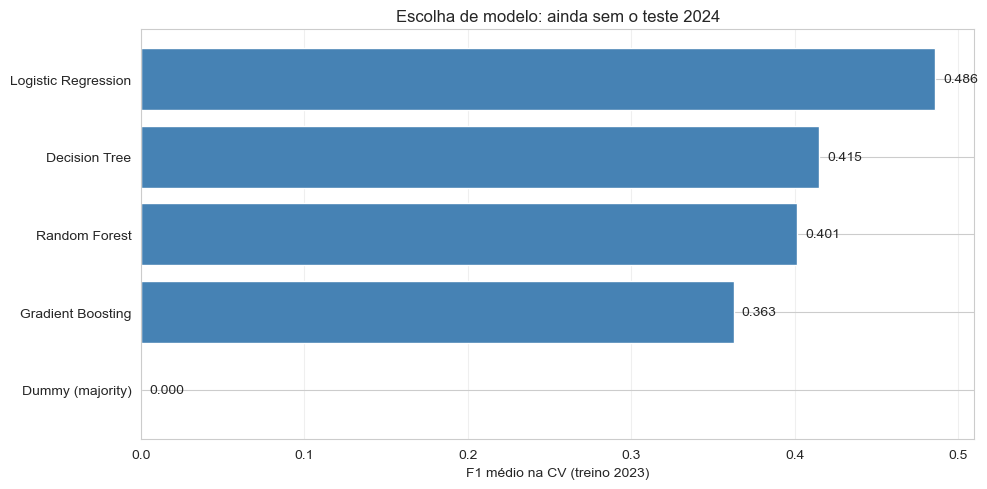

In [6]:
results_df = trainer.get_results_df()

print('COMPARAÇÃO — CV no treino 2023 (F1 da classe 1)')
print('=' * 100)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('=' * 100)

plot_df = results_df.dropna(subset=['CV F1']).sort_values('CV F1', ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['Model'], plot_df['CV F1'], color='steelblue')
ax.set_xlabel('F1 médio na CV (treino 2023)')
ax.set_title('Escolha de modelo: ainda sem o teste 2024')
ax.grid(axis='x', alpha=0.3)
for i, value in enumerate(plot_df['CV F1'].values):
    ax.text(value + 0.005, i, f'{value:.3f}', va='center')
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()


### Como ler o placar que acabou de aparecer

Números típicos desta base (podem mexer na terceira casa; a **ordem** não deve mudar):

| Palpite | F1 no simulado | O que isso quer dizer |
|---|---|---|
| **Regressão logística** | **cerca de 0,48** | **Ganhadora.** Pega a maioria de quem está na meta no *mesmo ano* 2023 (abrangência ~74%), mas a lista tem muitos “falso alarme” (precisão ~36%). Acerto equilibrado ~0,73 — **existe padrão** (geografia / participação). |
| Random Forest | ~0,41 | Perde da reta. Com poucas colunas, várias árvores não ajudam. |
| Árvore | ~0,40 | Parecida com a floresta, um pouco mais oscilante. |
| Gradient Boosting | ~0,37 | Medroso: quando aponta, acerta mais (~66% de precisão), mas deixa passar cerca de **3 em cada 4** que realmente estão na meta. |
| Dummy (sempre “fora”) | **0,00** | Chão no lugar. Se não for zero, a tabela de respostas está embaralhada. |

**Por que a logística ganha da floresta aqui?** O que restou é pouco e sobretudo “onde a cidade está e se a turma compareceu”. Uma reta com atenção à minoria encaixa isso; árvores tentam recortar 2023 fino demais e já perdem *dentro* do simulado.

#### **Ganhadora do treino: Regressão Logística**

Maior F1 no simulado (~0,48) **não prova** que ela será boa em 2024. Prova só: *entre estes palpites, sem abrir a prova de 2024, ela foi a melhor.*

Se um palpite tivesse F1 de simulado perto de **1,00**, haveria cola de novo — voltaríamos à seção 4.


## 9. Ajuste fino (Grid Search) — ainda no simulado

Até agora usamos a logística com os botões de fábrica.

**Hiperparâmetro** = botão que **nós** giramos *antes* do estudo, não o que o palpite aprende sozinho. Na logística o botão principal se chama **`C`**:

- `C` pequeno → reta mais **simples** (menos risco de decorar 2023);
- `C` grande → reta mais **solta** (pode colar no caderno de 2023).

**Grid Search** = experimentar uns poucos valores de `C` (uma “grade” pequena), cada um com os **mesmos** cinco simulados. Ficamos com o `C` de maior F1 médio.

Só o palpite que **já ia ganhando** entra na grade. Não gastamos a aula afinando uma floresta perdedora.

Depois da grade, o vencedor oficial continua sendo quem tiver o **maior F1 de simulado** (a logística crua ou a logística afinada). **2024 ainda está lacrado.**

Na prática o F1 costuma **quase não subir**. Isso já é recado: o problema não era o botão — era a falta de informação honesta.


In [7]:
cv_only = trainer.get_results_df()
cv_only = cv_only[~cv_only['Model'].str.contains('Dummy|Grid Search', regex=True)]
best_for_tuning = cv_only.iloc[0]['Model']
print(f'Modelo que entra no Grid Search: {best_for_tuning}')

trainer.optimize_hyperparameters(
    X_train, y_train,
    model_name=best_for_tuning,
)

best_model = trainer.select_best_model(metric='CV F1')

print('\nTabela depois do Grid Search:')
print(trainer.get_results_df().to_string(index=False, float_format=lambda x: f'{x:.4f}'))


Modelo que entra no Grid Search: Logistic Regression

GRID SEARCH: Logistic Regression  |  CV = GroupKFold(5) por município
Combinações: 3  |  parâmetros: ['classifier__C']
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Grid Search em 0.4s
Melhores parâmetros:
   classifier__C: 0.1
CV F1 do vencedor: 0.4881

MELHOR MODELO (escolhido pela CV no 2023)
   Logistic Regression (Grid Search)
   CV F1: 0.4881
   O teste 2024 ainda não foi usado.

Tabela depois do Grid Search:
                            Model  CV F1  CV F1 std  CV balanced acc  CV precision  CV recall  CV time (s)
Logistic Regression (Grid Search) 0.4881        NaN              NaN           NaN        NaN       0.4083
              Logistic Regression 0.4858     0.0186           0.7288        0.3621     0.7385       0.1508
                    Decision Tree 0.4149     0.0173           0.6518        0.3571     0.4970       0.1108
                    Random Forest 0.4013     0.0191           0.6400        0.3617  

### Como ler o Grid Search

O print deve dizer:

- qual palpite entrou (em geral **Logistic Regression**);
- quantas combinações da grade (poucos valores de `C`);
- o melhor `C`;
- o F1 de simulado do vencedor;
- o bloco **MELHOR MODELO (escolhido pela CV no 2023)**.

Se o F1 da grade for **quase o mesmo** ~0,48 da logística sem grade, escreva no relatório: *“o ajuste fino não era o gargalo.”* Não espere a prova de 2024 subir sozinha.

Só o objeto anunciado como melhor segue para a seção 10.


## 10. A prova de 2024 fica no notebook 04

A escolha do palpite **já foi feita** no simulado de 2023 (seções 6 a 9). Trazer os cinco modelos para 2024 e ficar com o maior número é escolher o caderno que deu sorte na prova.

**Neste notebook o 2024 não entra na nota.** O arquivo `models/best_model.pkl` é gravado na seção 11. O notebook 04 abre esse arquivo **uma vez**, com Dummy do próprio ano, matriz, ROC e erros por região.

Se você voltar nas seções 6 a 9 *depois* de ver 2024, o vestibular deixou de ser vestibular.


In [8]:
print('O teste 2024 nao e avaliado aqui.')
print('Notebook 04 abre models/best_model.pkl uma vez.')
print('Palpite escolhido no simulado 2023:', trainer.best_model_name)


O teste 2024 nao e avaliado aqui.
Notebook 04 abre models/best_model.pkl uma vez.
Palpite escolhido no simulado 2023: Logistic Regression (Grid Search)


### Como ler esta seção

Não deve aparecer F1 / acurácia de 2024 neste notebook. Se aparecer, o protocolo quebrou: apague a célula e rode o 04.

A seção 11 só grava o vencedor do simulado.


## 11. Guardar o vencedor

O palpite escolhido (logística afinada) vai para o arquivo `models/best_model.pkl`. A tabela do simulado vai num CSV ao lado.

O notebook 04 **só lê** esse arquivo. Não retreina, não reabre a grade, não olha os perdedores.

A predição em cinco linhas do 2024 é um “teste de fumaça”: o arquivo abre e devolve 0 ou 1? **Não** é uma nota nova.


In [9]:
trainer.save_model(filepath='../models/best_model.pkl')

loaded = ModelTrainer.load_model('../models/best_model.pkl')
sample_pred = loaded.predict(X_train.head())
print(f'Predicoes de fumaca (5 linhas do TREINO 2023): {sample_pred}')
print('Modelo gravado. Notebook 04 usa models/best_model.pkl.')



Modelo salvo em ../models/best_model.pkl
Resultados de CV salvos em ../models/model_comparison_results.csv
Carregando modelo de ../models/best_model.pkl...
Predicoes de fumaca (5 linhas do TREINO 2023): [0 0 0 0 0]
Modelo gravado. Notebook 04 usa models/best_model.pkl.


### Como ler o “arquivo salvo”

Se apareceu mensagem de sucesso e uma listinha tipo `[0 1 0 1 0]`, o arquivo está íntegro. Essa listinha **não** substitui a nota da seção 10. No notebook 04, aponte para `../models/best_model.pkl`.


## 12. Resumo para o relatório (e para quem não é da área)

### O que fizemos, em ordem

1. Pegamos a tabela do notebook 02 (município-ano; sim/não = na meta de 2024; estudo 2023 / prova 2024).
2. Tiramos o que ainda era cola: níveis da prova (só existem em 2024) e a rampa de metas municipais (quase a própria taxa).
3. Deixamos região, estado, participação e meta **do estado**.
4. Comparamos palpites **só** com simulados de 2023, nota **F1** (porque acurácia de 82% no “sempre fora” é mentira).
5. Afinamos só a ganhadora, ainda no simulado.
6. Abrimos 2024 **uma vez**.

### Quem ganhou o simulado, e por quê

**Regressão logística** (depois o Grid Search quase não muda o F1).

Ela ganhou porque o que restou é pouco e geográfico: uma reta com atenção à minoria (18% na meta) descreve 2023 melhor do que florestas. O Dummy fez F1 0: há *algum* padrão, não é ruído puro.

### Como foi a prova de 2024

Números típicos da logística:

| Métrica | Valor | Como ler |
|---|---|---|
| F1 | ~0,45 | Perde do chute “todo mundo na meta” (~0,70), porque em 2024 a metade já está na meta. |
| Acurácia | ~0,50 | Perde do mesmo chute (~53%). |
| Precisão | ~0,55 | Quase a proporção real (53%): a lista quase não filtra. |
| Recall | ~0,37 | Encontra ~37% de quem bateu a meta; os outros 63% passam batido. |
| **Acerto equilibrado** | **~0,51** | Comparar com 0,50. **Quase cara-ou-coroa.** |

**Isso é ruim como ferramenta de política:** não use este classificador para decidir quem vai cumprir a meta no ano que vem.

**Isso não é ruim como trabalho didático:** o teste justo mostrou o limite do Silver. Se a cola (taxa base, metas 2025–2029, média de português) tivesse ficado, o simulado iria a ~99% e o relatório mentiria.

### Frases prontas para copiar

1. *“O palpite foi escolhido em 2023 por F1 em validação cruzada, sem usar 2024.”*
2. *“A ganhadora foi a regressão logística; florestas não melhoraram com as colunas honestas.”*
3. *“Em 2024 o acerto equilibrado ficou em cerca de 0,51: o modelo não separa municípios na meta.”*
4. *“Acurácia e F1 no teste perdem de um chute sempre positivo; por isso não são a leitura principal neste ano.”*

### O que não fazer agora

- Trocar para Random Forest porque “no teste poderia ser maior”.
- Recolocar taxa base / metas anuais para “melhorar a métrica”.
- Vender 50% de acerto como sucesso.

**Próximo passo:** notebook 04 — *onde* o palpite erra em 2024 (em geral: ainda pensa com a cabeça de 2023, quando “na meta” era raro).
